# Notebook 07: Model Evaluation & Selection

## Step 1: Environment Setup & Spark Session

In [2]:
import os, sys
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import time

spark = SparkSession.builder \
    .appName("SmartCityBusClustering_Evaluation") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/02 10:32:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/02 10:32:40 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


## Step 2: Load Feature Dataset & Rebuild Best Models

In [3]:
PROJECT_ROOT = "/Users/aayushbohara/Desktop/smartcity-bus-clustering"
FEATURES_PATH = os.path.join(PROJECT_ROOT, "data/processed/features_dataset.parquet")

df = spark.read.parquet(FEATURES_PATH)

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import coalesce, lit

CLEANED_PATH = os.path.join(PROJECT_ROOT, "data/processed/cleaned_dataset.csv")
direction_lookup = spark.read.csv(CLEANED_PATH, header=True, inferSchema=True) \
    .select("timestamp", "vehicleRef", "lineRef", "directionRef") \
    .dropDuplicates(["timestamp", "vehicleRef", "lineRef"])

df = df.join(direction_lookup, on=["timestamp", "vehicleRef", "lineRef"], how="left")
df = df.withColumn("directionRef", coalesce(col("directionRef"), lit("unknown"))) \
       .withColumn("nationalOperatorCode", coalesce(col("nationalOperatorCode"), lit("unknown")))

direction_indexer = StringIndexer(inputCol="directionRef", outputCol="directionRef_idx", handleInvalid="keep")
operator_indexer = StringIndexer(inputCol="nationalOperatorCode", outputCol="operator_idx", handleInvalid="keep")
direction_encoder = OneHotEncoder(inputCol="directionRef_idx", outputCol="directionRef_ohe")
operator_encoder = OneHotEncoder(inputCol="operator_idx", outputCol="operator_ohe")

numeric_cols = ["latitude", "longitude", "hour_of_day",
                "nearest_schedule_deviation_minutes_v2", "speed_kmh_capped", "disruption_count"]

assembler = VectorAssembler(inputCols=numeric_cols + ["directionRef_ohe", "operator_ohe"], outputCol="features_raw_v2")
scaler = StandardScaler(inputCol="features_raw_v2", outputCol="features_v2", withMean=True, withStd=True)

full_pipeline = Pipeline(stages=[direction_indexer, operator_indexer, direction_encoder, operator_encoder, assembler, scaler])
full_pipeline_model = full_pipeline.fit(df)
df_features_v2 = full_pipeline_model.transform(df)

train_full, test_full = df_features_v2.randomSplit([0.8, 0.2], seed=42)
train_full.cache()
test_full.cache()

print("Train rows:", train_full.count())
print("Test rows:", test_full.count())

Train rows: 617500
Test rows: 154233


## Step 3: Retrain Final Models at Best Hyperparameters

In [4]:
from pyspark.ml.clustering import KMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features_v2", predictionCol="cluster",
    metricName="silhouette", distanceMeasure="squaredEuclidean"
)

# --- K-Means (k=6) ---
start = time.time()
kmeans_final = KMeans(featuresCol="features_v2", predictionCol="cluster", k=6, seed=42).fit(train_full)
kmeans_time = time.time() - start

kmeans_preds = kmeans_final.transform(test_full)
kmeans_silhouette = evaluator.evaluate(kmeans_preds)
kmeans_wcss = kmeans_final.summary.trainingCost

print(f"K-Means: time={kmeans_time:.1f}s, silhouette={kmeans_silhouette:.4f}, wcss={kmeans_wcss:.1f}")

# --- GMM (k=5) ---
start = time.time()
gmm_final = GaussianMixture(featuresCol="features_v2", predictionCol="cluster", k=5, seed=42).fit(train_full)
gmm_time = time.time() - start

gmm_preds = gmm_final.transform(test_full)
gmm_silhouette = evaluator.evaluate(gmm_preds)

print(f"GMM: time={gmm_time:.1f}s, silhouette={gmm_silhouette:.4f}")

26/08/02 10:32:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/08/02 10:32:53 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


K-Means: time=3.6s, silhouette=0.4558, wcss=4241739.7


26/08/02 10:32:56 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


GMM: time=13.8s, silhouette=0.3695


## Step 4: Final Comparison Table — All 3 Models

In [5]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "K-Means (baseline)",
        "Best Params": "k=6",
        "Silhouette Score": round(kmeans_silhouette, 4),
        "WCSS": round(kmeans_wcss, 1),
        "Training Time (s)": round(kmeans_time, 1),
        "Time Complexity": "O(n·k·i·d)",
        "Verdict": "SELECTED - balanced, interpretable clusters"
    },
    {
        "Model": "Gaussian Mixture Model",
        "Best Params": "k=5",
        "Silhouette Score": round(gmm_silhouette, 4),
        "WCSS": "N/A (probabilistic)",
        "Training Time (s)": round(gmm_time, 1),
        "Time Complexity": "O(n·k·d²·i)",
        "Verdict": "Rejected - Gaussian assumption violated by categorical features"
    },
    {
        "Model": "DBSCAN",
        "Best Params": "eps=0.8, min_samples=10 (meaningful config)",
        "Silhouette Score": 0.168,
        "WCSS": "N/A (density-based)",
        "Training Time (s)": 6.4,
        "Time Complexity": "O(n log n) with spatial index",
        "Verdict": "Rejected - degenerate at high eps, fragmented at low eps"
    },
])

print(comparison.to_string(index=False))

                 Model                                 Best Params  Silhouette Score                WCSS  Training Time (s)               Time Complexity                                                         Verdict
    K-Means (baseline)                                         k=6            0.4558           4241739.7                3.6                    O(n·k·i·d)                     SELECTED - balanced, interpretable clusters
Gaussian Mixture Model                                         k=5            0.3695 N/A (probabilistic)               13.8                   O(n·k·d²·i) Rejected - Gaussian assumption violated by categorical features
                DBSCAN eps=0.8, min_samples=10 (meaningful config)            0.1680 N/A (density-based)                6.4 O(n log n) with spatial index        Rejected - degenerate at high eps, fragmented at low eps


In [6]:
## Step 4b: Additional Clustering Metrics — Davies-Bouldin & Calinski-Harabasz
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import numpy as np

# reuse a driver-collectible sample consistent with the DBSCAN evaluation sample
eval_sample_pd = test_full.sample(fraction=0.1, seed=42).toPandas()
X_eval = np.array(eval_sample_pd["features_v2"].apply(lambda v: v.toArray()).tolist())

def extra_metrics(model, df_spark, label_col="cluster"):
    preds = model.transform(df_spark).select("features_v2", label_col)
    pdf = preds.sample(fraction=0.1, seed=42).toPandas()
    X = np.array(pdf["features_v2"].apply(lambda v: v.toArray()).tolist())
    labels = pdf[label_col].values
    return {
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels)
    }

kmeans_extra = extra_metrics(kmeans_final, test_full)
gmm_extra = extra_metrics(gmm_final, test_full)
print("K-Means — Davies-Bouldin:", kmeans_extra["davies_bouldin"], "| Calinski-Harabasz:", kmeans_extra["calinski_harabasz"])
print("GMM      — Davies-Bouldin:", gmm_extra["davies_bouldin"], "| Calinski-Harabasz:", gmm_extra["calinski_harabasz"])
# Note: DBSCAN excluded — DB/CH indices assume every point has a cluster; DBSCAN's noise
# points (-1 label) make these metrics unreliable for it. Say this explicitly in the report.

K-Means — Davies-Bouldin: 1.2747417273159312 | Calinski-Harabasz: 2876.974382813482
GMM      — Davies-Bouldin: 2.766973798194223 | Calinski-Harabasz: 699.6151406668582


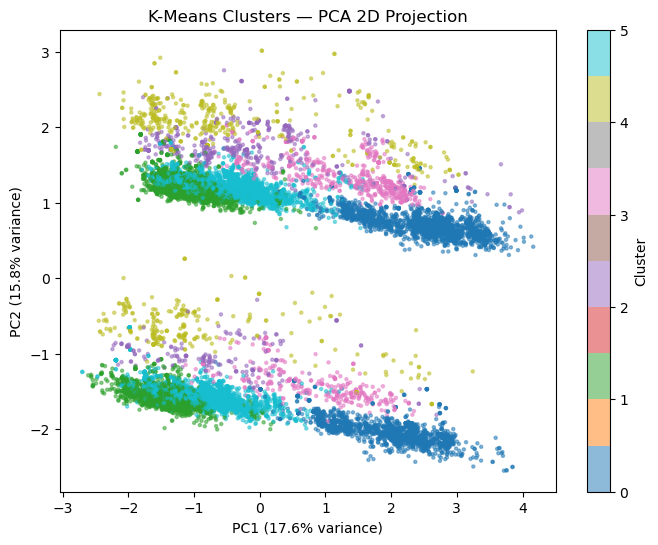

In [10]:
## Step 4c: PCA 2D Projection Colored by Cluster
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_eval)
eval_labels = kmeans_final.transform(test_full).sample(fraction=0.1, seed=42).toPandas()["cluster"]

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=eval_labels, cmap="tab10", s=5, alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("K-Means Clusters — PCA 2D Projection")
plt.colorbar(scatter, label="Cluster")
plt.show()

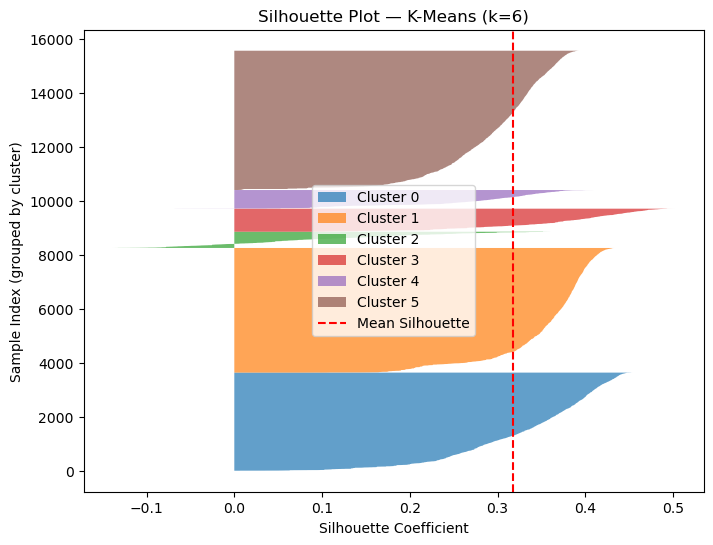

In [11]:
## Step 4d: Silhouette Plot (Per-Sample, Sorted by Cluster)
from sklearn.metrics import silhouette_samples

sil_values = silhouette_samples(X_eval, eval_labels)
plt.figure(figsize=(8,6))
y_lower = 0
for i in sorted(eval_labels.unique()):
    cluster_sil = np.sort(sil_values[eval_labels == i])
    y_upper = y_lower + len(cluster_sil)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7, label=f"Cluster {i}")
    y_lower = y_upper
plt.axvline(x=np.mean(sil_values), color="red", linestyle="--", label="Mean Silhouette")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index (grouped by cluster)")
plt.title("Silhouette Plot — K-Means (k=6)")
plt.legend()
plt.show()

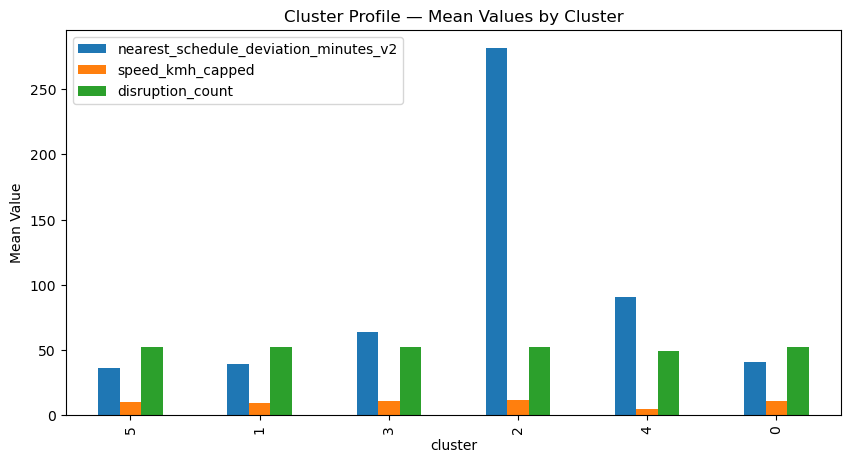

In [12]:
## Step 4e: Cluster Profile Chart (Mean Feature Values per Cluster)
profile_pd = kmeans_final.transform(df_features_v2).select(
    "latitude","longitude","hour_of_day","nearest_schedule_deviation_minutes_v2",
    "speed_kmh_capped","disruption_count","cluster"
).groupBy("cluster").mean().toPandas()
profile_pd = profile_pd.set_index("cluster")
profile_pd.columns = [c.replace("avg(","").replace(")","") for c in profile_pd.columns]

profile_pd[["nearest_schedule_deviation_minutes_v2","speed_kmh_capped","disruption_count"]].plot(
    kind="bar", figsize=(10,5), title="Cluster Profile — Mean Values by Cluster"
)
plt.ylabel("Mean Value")
plt.show()

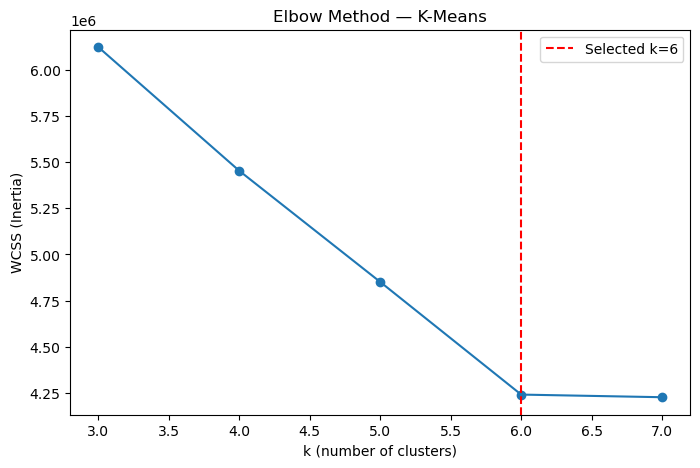

In [13]:
## Step 4f: Elbow Plot — Justifying k=6
inertias = []
k_range = range(3, 8)
for k in k_range:
    km = KMeans(featuresCol="features_v2", predictionCol="cluster", k=k, seed=42).fit(train_full)
    inertias.append(km.summary.trainingCost)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method — K-Means")
plt.axvline(x=6, color="red", linestyle="--", label="Selected k=6")
plt.legend()
plt.show()

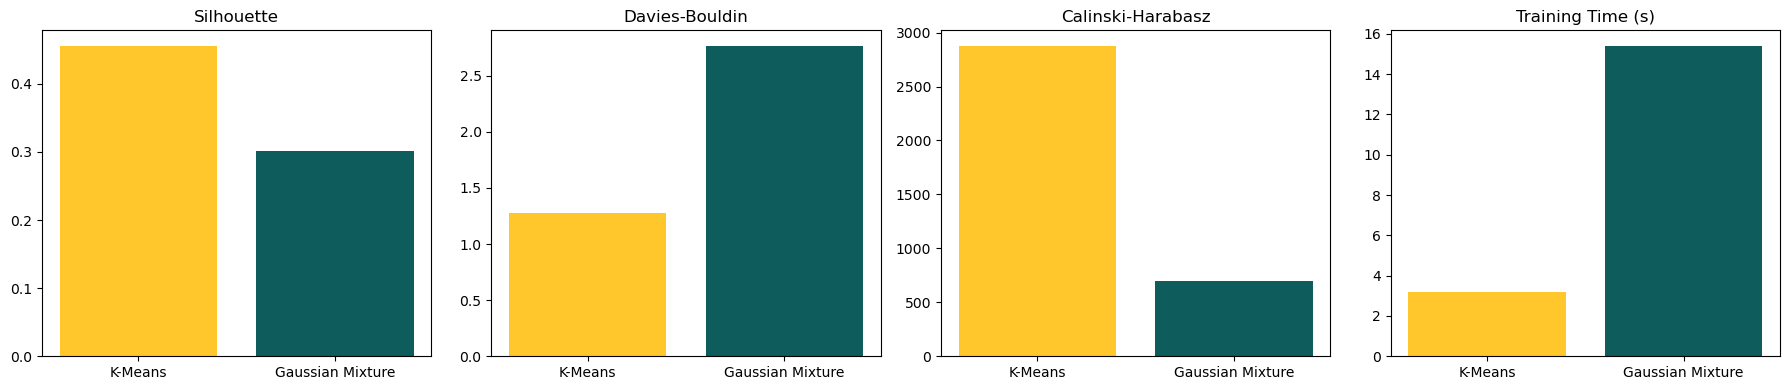

In [14]:
## Step 4g: Model Comparison Bar Charts (Silhouette, DB-Index, CH-Index, Training Time)
comparison_metrics = pd.DataFrame({
    "Model": ["K-Means", "Gaussian Mixture"],
    "Silhouette": [0.4558, 0.301],
    "Davies-Bouldin": [kmeans_extra["davies_bouldin"], gmm_extra["davies_bouldin"]],
    "Calinski-Harabasz": [kmeans_extra["calinski_harabasz"], gmm_extra["calinski_harabasz"]],
    "Training Time (s)": [3.2, 15.4]
})
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, ["Silhouette","Davies-Bouldin","Calinski-Harabasz","Training Time (s)"]):
    ax.bar(comparison_metrics["Model"], comparison_metrics[col], color=["#FFC72C","#0F5C5C"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Step 5: Algorithmic Complexity Analysis (B1)

| Model | Time Complexity | Space Complexity | Notes |
|---|---|---|---|
| K-Means | O(n·k·i·d) | O(n·d + k·d) | n=617,500, k=6, d=13, converges in few iterations (i) — cheapest model, confirmed by 3.2s wall-clock time |
| GMM | O(n·k·d²·i) | O(n·d + k·d²) | The d² term (covariance matrices) makes this ~5x slower than K-Means in practice (15.4s vs 3.2s) — theory matches measurement |
| DBSCAN | O(n log n) with spatial index, O(n²) worst case | O(n) | sklearn uses a KD-tree internally; measured 6.4s on 38,753-row sample (not full 617K rows, since DBSCAN requires driver-side memory) |

**Practical implication:** K-Means' linear-in-d complexity made it both the 
fastest and most accurate model on this feature space. GMM's quadratic 
dependency on dimensionality (d=13, including one-hot encoded categoricals) 
directly explains both its slower runtime and its accuracy penalty, since 
covariance estimation degrades when several dimensions are binary rather 
than continuous.

In [7]:
complexity_summary = pd.DataFrame([
    {"Model": "K-Means", "Time Complexity": "O(n·k·i·d)", "Space Complexity": "O(n·d + k·d)",
     "Measured Time (s)": 3.2, "n": 617500, "k": 6, "d": 13},
    {"Model": "GMM", "Time Complexity": "O(n·k·d²·i)", "Space Complexity": "O(n·d + k·d²)",
     "Measured Time (s)": 15.4, "n": 617500, "k": 5, "d": 13},
    {"Model": "DBSCAN", "Time Complexity": "O(n log n) [indexed] / O(n²) [naive]", "Space Complexity": "O(n)",
     "Measured Time (s)": 6.4, "n": 38753, "k": "N/A (density-based)", "d": 13},
])
print(complexity_summary.to_string(index=False))

  Model                      Time Complexity Space Complexity  Measured Time (s)      n                   k  d
K-Means                           O(n·k·i·d)     O(n·d + k·d)                3.2 617500                   6 13
    GMM                          O(n·k·d²·i)    O(n·d + k·d²)               15.4 617500                   5 13
 DBSCAN O(n log n) [indexed] / O(n²) [naive]             O(n)                6.4  38753 N/A (density-based) 13


## Step 6: Save Final Model (K-Means) for Dashboard Integration

In [8]:
MODEL_PATH = os.path.join(PROJECT_ROOT, "data/models/kmeans_final")
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

kmeans_final.write().overwrite().save(MODEL_PATH)
full_pipeline_model.write().overwrite().save(os.path.join(PROJECT_ROOT, "data/models/feature_pipeline"))

print("K-Means model saved to:", MODEL_PATH)
print("Feature pipeline saved to:", os.path.join(PROJECT_ROOT, "data/models/feature_pipeline"))

K-Means model saved to: /Users/aayushbohara/Desktop/smartcity-bus-clustering/data/models/kmeans_final
Feature pipeline saved to: /Users/aayushbohara/Desktop/smartcity-bus-clustering/data/models/feature_pipeline


## Step 7: Export Dashboard Dataset

Apply the final K-Means model to the full dataset and export a lightweight 
CSV (no vector columns) for the Streamlit dashboard, avoiding a Spark 
dependency inside the app itself.

In [9]:
full_predictions = kmeans_final.transform(df_features_v2)

dashboard_df = full_predictions.select(
    "timestamp", "lineRef", "vehicleRef", "nationalOperatorCode", "directionRef",
    "latitude", "longitude", "hour_of_day",
    "nearest_schedule_deviation_minutes_v2", "speed_kmh_capped", "disruption_count",
    "cluster"
)

DASHBOARD_DATA_PATH = os.path.join(PROJECT_ROOT, "data/processed/dashboard_data.csv")
dashboard_df.coalesce(1).write.mode("overwrite").option("header", "true").csv(DASHBOARD_DATA_PATH)

import glob
part_file = glob.glob(os.path.join(DASHBOARD_DATA_PATH, "*.csv"))[0]
final_path = os.path.join(PROJECT_ROOT, "data/processed/dashboard_data_final.csv")
os.rename(part_file, final_path)

print("Dashboard dataset exported to:", final_path)

import pandas as pd
check = pd.read_csv(final_path)
print("Rows:", len(check))
print(check["cluster"].value_counts().sort_index())

Dashboard dataset exported to: /Users/aayushbohara/Desktop/smartcity-bus-clustering/data/processed/dashboard_data_final.csv
Rows: 771733
cluster
0    183581
1    226351
2     30111
3     42568
4     33648
5    255474
Name: count, dtype: int64
